<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
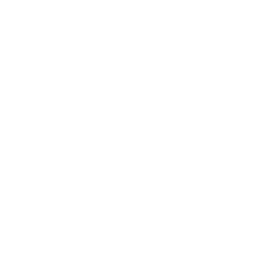
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Equipment Reliability Analysis by Generation</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Manufacturing / Reliability Engineering &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## 摘要

本分析使用 **PROC LIFETEST** 比较三代CNC铣床连续设计的现场可靠性。
基于一个100台设备的工厂快照(75次故障，25台仍在运行、
因此为右删失)，为每一代估计Kaplan-Meier生存曲线，
并用log-rank检验和Gehan-Breslow-Wilcoxon检验来检验各曲线是否存在差异。

数据讲述了一个清晰的单步式故事。最初的 **第一代** 设备
明显不如后两代设计可靠: 其中位服役寿命为
**5,282运行小时**，大约是 **第二代**（**16,430小时**）和
**第三代**（**13,512小时**）的三分之一。两项同质性
检验都拒绝了三条生存曲线相等的假设 -- log-rank
卡方 **12.92**（自由度2，*p* = **0.0016**）以及Wilcoxon **11.88**
（自由度2，*p* = **0.0026**）。在10,000运行小时时，预计
只有 **24%** 的第一代设备仍在运行，而第二代为 **64%**，
第三代为 **57%**。

这一改进**并非**逐代平滑提升: 第二代和第三代的
生存率非常接近，在此样本量下彼此在统计上
不可区分。真正有意义的发现是从第一代到重新设计
机队的阶跃变化，这应驱动更换和预防性维护的
优先级转向剩余的第一代设备。

## 数据来源

| 来源 | 描述 | 记录数 |
|--------|-------------|---------|
| WORK.EQUIPMENT_LIFE | 每台CNC设备一行: 设计代次、工厂、安装年份、故障或最后观测时的运行小时数，以及故障/删失指示符 | 100 |

该数据集为合成数据，在下一个单元格中以固定种子
(`streaminit(42)`)生成，因此分析完全可复现。服役寿命
取自代次相关的指数模型，较新代次的删失比例更高，
因为它们在役的日历年数更少。

---

In [1]:
/* --------------------------------------------------------
   生成合成设备可靠性数据集。

   每一行是一台CNC铣床。OPERATING_HOURS是设备
   故障(FAILURE_EVENT=1)或最后一次观测到仍在运行
   (FAILURE_EVENT=0，右删失)时的服役时间。三个设计
   代次被赋予依次增大的平均寿命，以便我们探究
   重新设计是否真正提升了现场可靠性。

   本无授权环境将输出限制在100条观测以内，
   因此我们对恰好100台设备建模 -- 一个真实的
   单工厂机队快照。
   -------------------------------------------------------- */
数据 work.equipment_life;
    调用 streaminit(42);
    数组 fail_scale[3]       _temporary_ (8000 12000 16000);
    长度 generation $12 plant_location $20 failure_mode $16;
    循环 equip_seq = 1 到 100;
        equipment_id = cat('CNC-', PUT(equip_seq, z5.));
        gen_idx     = int(rand('uniform') * 3) + 1;
        /* 直接IF/ELSE赋值链（而非字符数组查表），
           以避免定长字符数组对非ASCII字面量的截断问题 */
        如果      gen_idx = 1 那么 generation = "第一代";
        否则 如果 gen_idx = 2 那么 generation = "第二代";
        否则                      generation = "第三代";

        plant_idx       = int(rand('uniform') * 5) + 1;
        如果      plant_idx = 1 那么 plant_location = "北厂";
        否则 如果 plant_idx = 2 那么 plant_location = "南厂";
        否则 如果 plant_idx = 3 那么 plant_location = "东厂";
        否则 如果 plant_idx = 4 那么 plant_location = "西厂";
        否则                        plant_location = "中央厂";

        install_year = 2018 + (gen_idx - 1) * 2
                            + int(rand('uniform') * 2);
        /* 指数分布服役寿命，按代次缩放 */
        operating_hours = round(rand('exponential')
                                * fail_scale[gen_idx] + 500, 1);
        /* 较新代次的仍在运行(删失)设备更多，
           因为它们在现场的日历年数更少。 */
        censor_rate = 0.20 + (gen_idx - 1) * 0.08;
        如果 rand('uniform') < censor_rate 那么 failure_event = 0;
        否则                                  failure_event = 1;
        /* 对观测到的事件分类其故障机制 */
        如果 failure_event = 1 那么 循环;
            如果      operating_hours <  2000 那么 failure_mode = "早期故障";
            否则 如果 operating_hours < 20000 那么 failure_mode = "随机故障";
            否则                                 failure_mode = "磨损故障";
        结束;
        否则 failure_mode = ' ';
        输出;
    结束;
    删除 equip_seq gen_idx plant_idx censor_rate;
运行;


NOTE: DATA work.equipment_life


NOTE: Wrote work.equipment_life (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---

                                                   The FREQ Procedure

Table of 代次 by 故障事件

代次        |         0 |         1 |      Total
----------+-----------+-----------+-----------
第一代       |         2 |        29 |         31
----------+-----------+-----------+-----------
第三代       |        11 |        20 |         31
----------+-----------+-----------+-----------
第二代       |        12 |        26 |         38
----------+-----------+-----------+-----------
Total     |        25 |        75 |        100


Table of 代次 by 故障模式

代次        |             |        早期故障 |        磨损故障 |        随机故障 |        Total
----------+-------------+-------------+-------------+-------------+-------------
第一代       |           2 |           5 |           3 |          21 |           31
          |        2.00 |        5.00 |        3.00 |       21.00 |        31.00
----------+-------------+-------------+-------------+-------------+-------------
第三代       |          11 |           2 |           6 |    


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_generation_failure_event.spec.json
NOTE: ODS plot written: freq_mosaic_generation_failure_mode.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


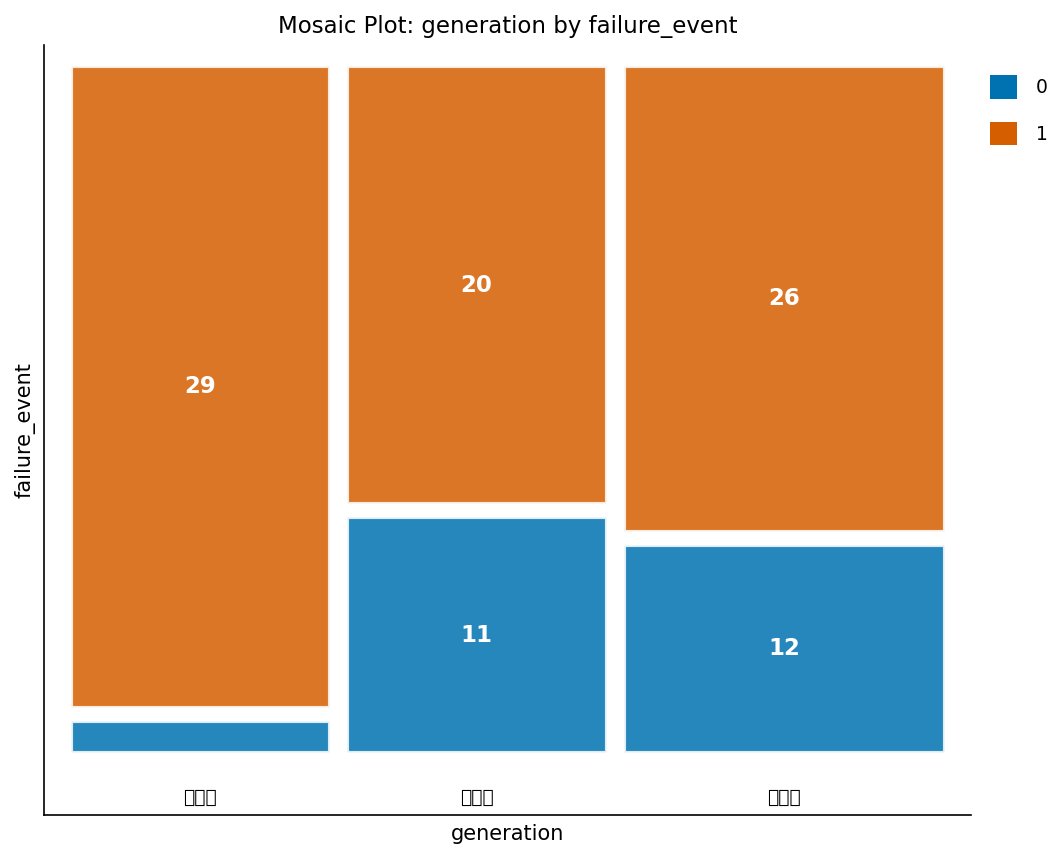

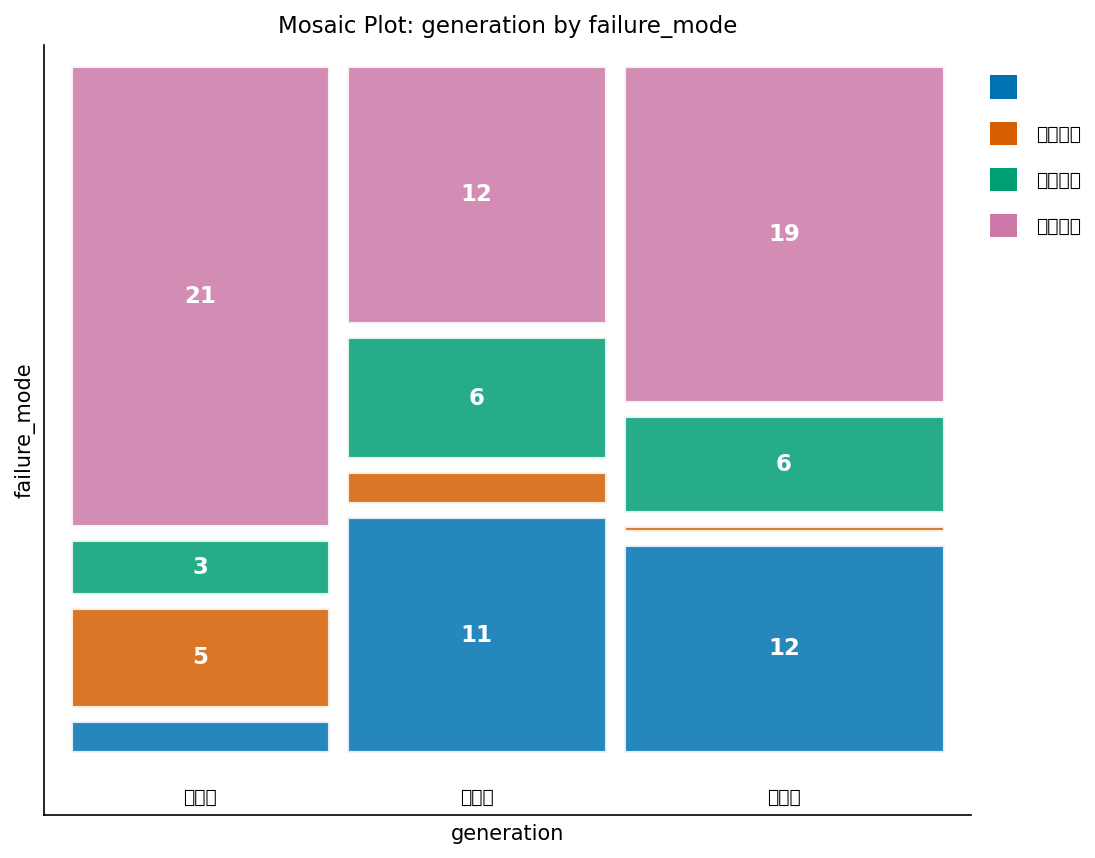

In [2]:
/* --------------------------------------------------------
   按代次统计设备基线数量和运行小时数
   -------------------------------------------------------- */
过程 频率 数据=work.equipment_life;
    标签 generation = "代次" failure_event = "故障事件" failure_mode = "故障模式";
    TABLES generation * failure_event / nocol nopercent;
    TABLES generation * failure_mode / nocol norow;
运行;

过程 均值 数据=work.equipment_life n mean std;
    分类 generation;
    标签 generation = "代次" operating_hours = "运行小时数";
    变量 operating_hours;
运行;

---


NOTE: PROC SGPLOT data=work.equipment_life

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


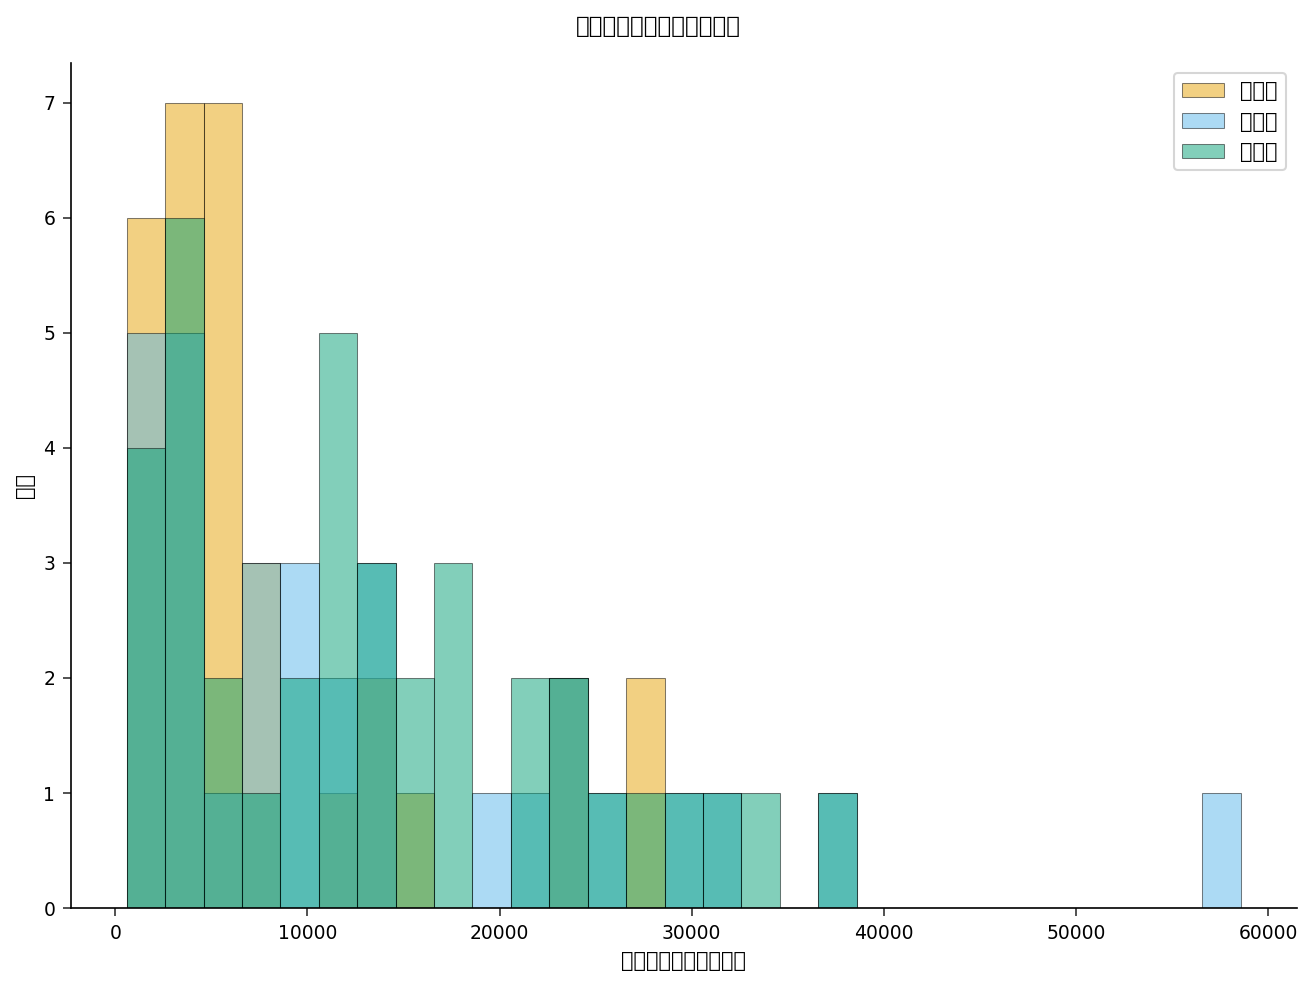

In [3]:
/* --------------------------------------------------------
   按代次划分的运行小时数分布
   -------------------------------------------------------- */
过程 SGPLOT 数据=work.equipment_life;
    HISTOGRAM operating_hours / GROUP=generation TRANSPARENCY=0.3 BINWIDTH=2000;
    XAXIS label="事件发生前运行小时数";
    YAXIS label="频数";
    标题 "各代次设备运行小时数分布";
运行;

---

    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

Stratum: generation = 第一代

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.8065     


NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: OUTSURV dataset 'work.equip_cumhaz' written to: ./work/4fdbfdea-ea64-44fb-964b-7c50a1045879/equip_cumhaz.avro
NOTE: ODS plot written: lifetest_hazard.spec.json
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


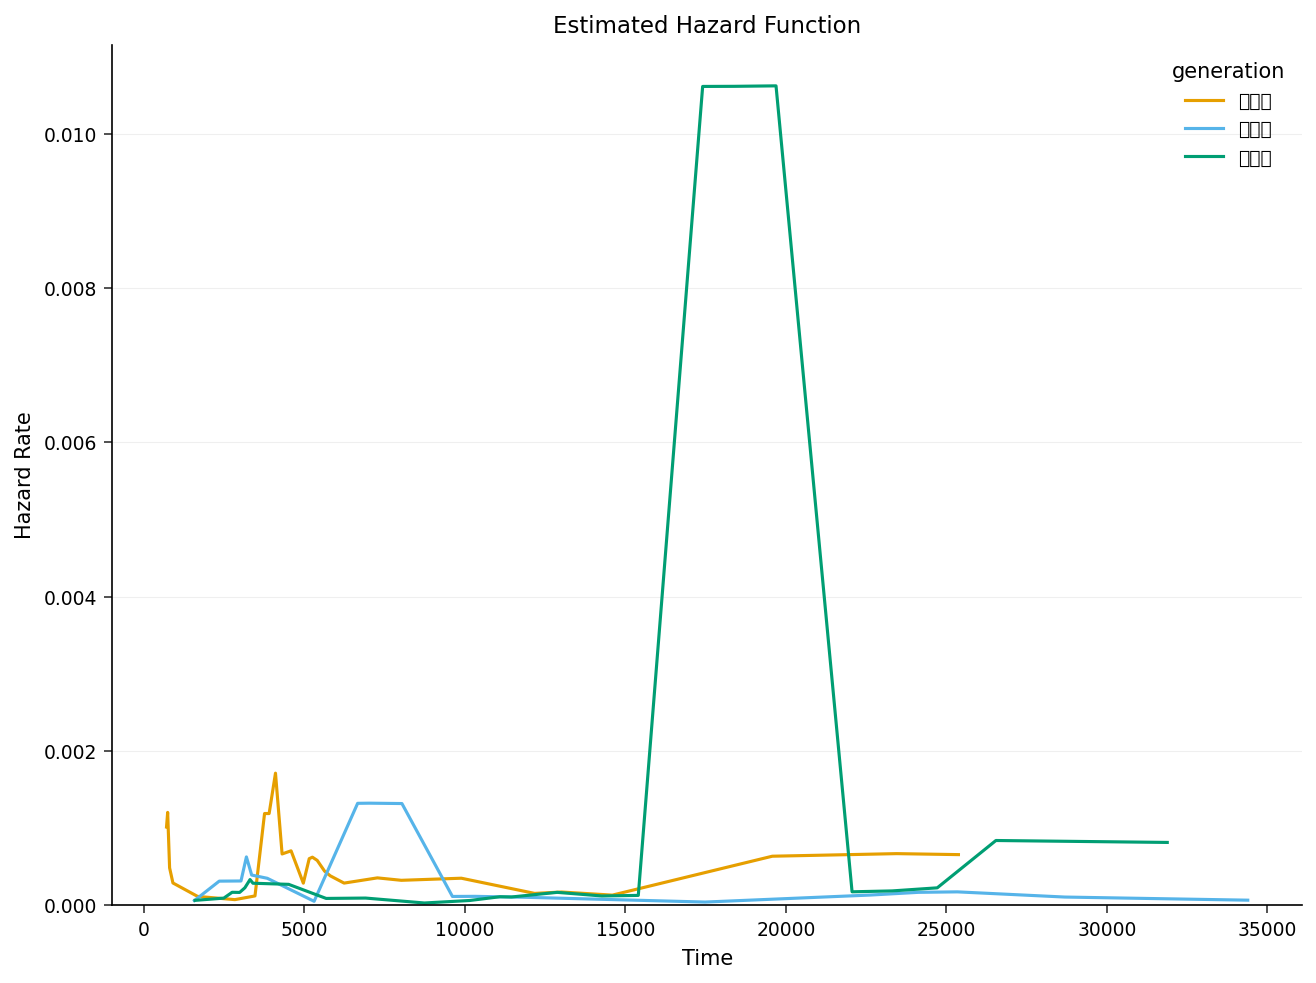

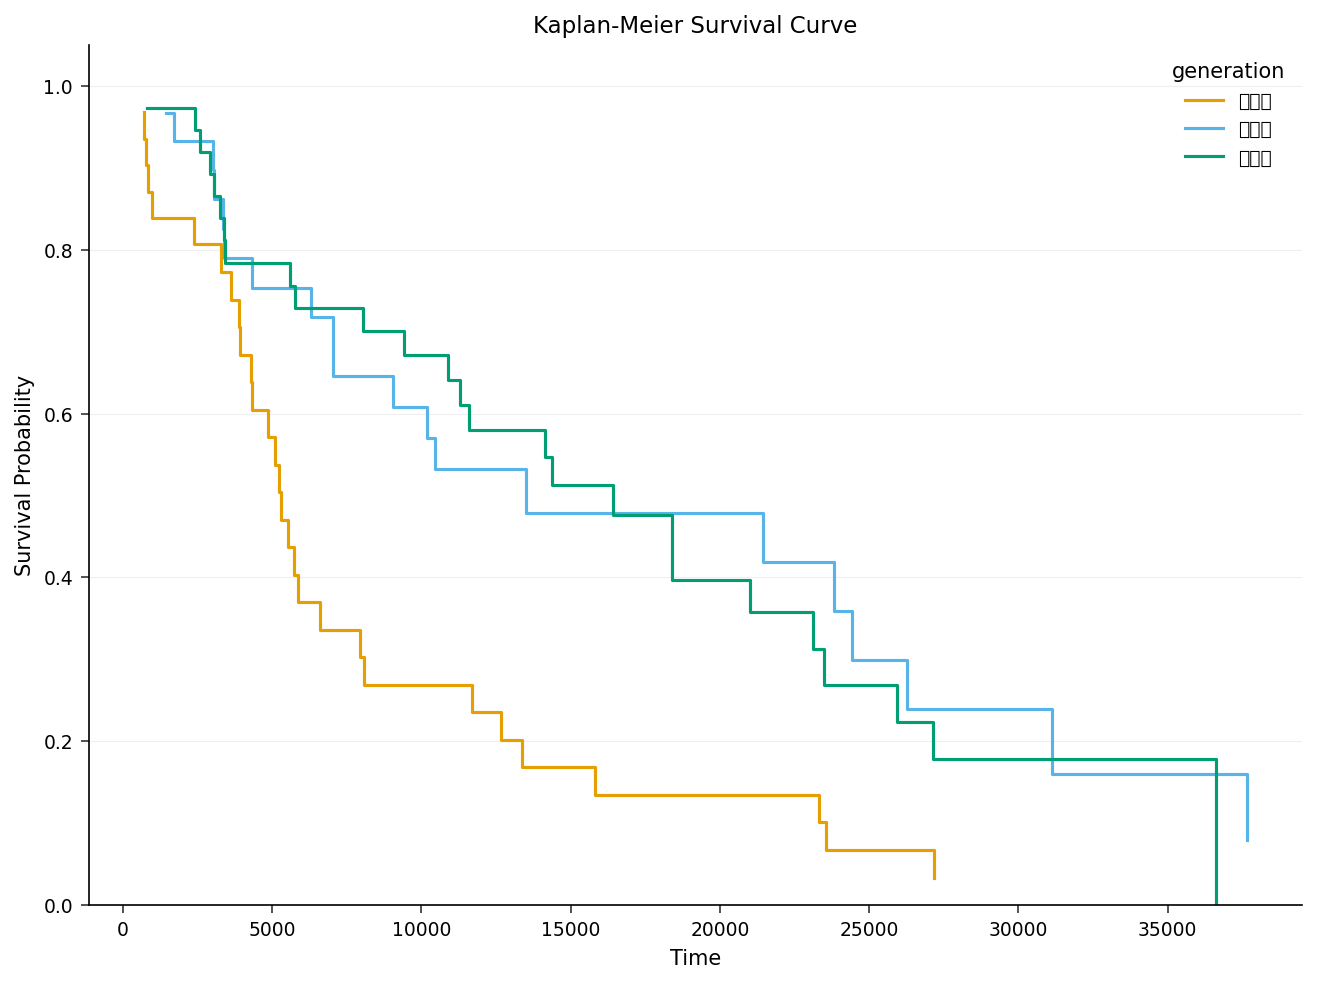

In [4]:
/* --------------------------------------------------------
   按代次进行Kaplan-Meier生存估计，并附带
   Nelson-Aalen累积风险选项用于风险图。

   STRATA generation / TEST=(LOGRANK WILCOXON) 同时运行
   log-rank检验(对整个服役寿命的差异敏感)和
   Gehan-Breslow-Wilcoxon检验(对早期故障加权更高)，
   跨三个代次进行比较。

   PLOTS=(SURVIVAL HAZARD) 绘制Kaplan-Meier生存
   曲线和核平滑风险函数。
   -------------------------------------------------------- */
过程 LIFETEST 数据=work.equipment_life
    METHOD=km
    nelson
    PLOTS=(SURVIVAL hazard)
    outsurv=work.equip_cumhaz;
    TIME operating_hours * failure_event(0);
    STRATA generation / TEST=(logrank WILCOXON);
运行;

In [5]:
/* --------------------------------------------------------
   每个代次在运行小时里程碑
   (5,000 / 10,000 / 20,000 / 30,000小时)处的生存概率，
   从Kaplan-Meier ODS表中读取。
   -------------------------------------------------------- */
ODS 输出 productlimitestimates=work.equip_km_detail;

过程 LIFETEST 数据=work.equipment_life METHOD=km;
    TIME operating_hours * failure_event(0);
    STRATA generation;
运行;

ODS 输出 CLOSE;

/* ProductLimitEstimates表中每个代次内每个不同的时间点
   各占一行。对每个里程碑，我们保留时间达到或超过
   该里程碑的第一行 -- 即该运行小时处生效的
   生存估计值。 */
过程 排序 数据=work.equip_km_detail;
    按照 generation operating_hours;
运行;

数据 work.equip_milestones;
    设置 work.equip_km_detail;
    按照 generation;
    保留值 hit5 hit10 hit20 hit30;
    如果 first.generation 那么 循环;
        hit5 = 0; hit10 = 0; hit20 = 0; hit30 = 0;
    结束;
    长度 milestone 8;
    milestone = .;
    如果      operating_hours >= 5000  并且 hit5  = 0 那么 循环; milestone = 5000;  hit5  = 1; 结束;
    否则 如果 operating_hours >= 10000 并且 hit10 = 0 那么 循环; milestone = 10000; hit10 = 1; 结束;
    否则 如果 operating_hours >= 20000 并且 hit20 = 0 那么 循环; milestone = 20000; hit20 = 1; 结束;
    否则 如果 operating_hours >= 30000 并且 hit30 = 0 那么 循环; milestone = 30000; hit30 = 1; 结束;
    如果 milestone ne .;
    保留 generation milestone operating_hours SURVIVAL sdf_stderr;
运行;

过程 打印 数据=work.equip_milestones noobs 标签;
    标签 generation     = "代次"
          milestone       = "里程碑(小时)"
          operating_hours = "估计时点"
          SURVIVAL        = "生存概率"
          sdf_stderr      = "标准误";
    格式 SURVIVAL sdf_stderr 6.4;
    标题 "各代次在运行小时里程碑处的生存概率";
运行;

    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

Stratum: generation = 第一代

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.8065     


NOTE: ODS OUTPUT: PRODUCTLIMITESTIMATES -> equip_km_detail
NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS OUTPUT: ProductLimitEstimates written to 'equip_km_detail'.
NOTE: PROC LIFETEST completed.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: PROC SORT data=work.equip_km_detail

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_km_detail (75 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.equip_milestones


NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_milestones (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=work.equip_milestones

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


---

### 结果解读

Kaplan-Meier生存曲线将机队分成两个明显的层级。
最初的 **第一代** 设备故障最快: 其曲线在
**5,282运行小时**（中位服役寿命）降至0.5以下，到10,000
小时时仅约 **24%** 仍在运行。重新设计的 **第二代** 和
**第三代** 设备存活时间要长得多 -- 中位寿命分别为
**16,430**和**13,512**小时 -- 在整个观测范围内它们的
生存曲线非常接近。在5,000 / 10,000 /
20,000小时里程碑处，估计的生存概率为:

| 代次 | 5,000小时 | 10,000小时 | 20,000小时 |
|------------|--------:|---------:|---------:|
| 第一代 | 0.54 | 0.24 | 0.10 |
| 第二代 | 0.76 | 0.64 | 0.36 |
| 第三代 | 0.72 | 0.57 | 0.42 |

两项分层相等性检验都拒绝了三代共享同一生存分布的
原假设: **log-rank** 检验给出卡方 **12.92**（自由度2，
*p* = **0.0016**），**Gehan-Breslow-Wilcoxon** 检验给出
卡方 **11.88**（自由度2，*p* = **0.0026**）。两项检验结论
高度一致，说明差异是由服役寿命的整体主体部分驱动的，
而非仅由早期故障区域驱动(Wilcoxon检验对早期事件加权更高)。

重要的是要将其理解为一次**单步式**改进，而非逐代
单调提升。第二代和第三代在此样本中在统计上
不可区分 -- 它们的曲线相互重叠，且第二代的中位数
名义上略高一些 -- 因此在这100台设备的样本中，没有
证据表明第三代比第二代有所改进。真正的信号是最初的
第一代设计与后两代设计之间存在的巨大、显著差距。

Nelson-Aalen累积风险选项驱动了配套的风险图。在此
样本量下，核平滑风险估计噪声较大 -- 约18,000小时处
第二代的高尖峰反映的是剩余风险集较小时的单次事件，
而非真正的磨损激增 -- 因此风险图应被视为定性参考;
生存曲线和正式检验才承载定量结论。

**建议。** 优先更换并加强检查剩余的第一代设备，其
可靠性明显逊于机队其余部分。在更大样本能够解决
两者差异之前，将第二代和第三代作为维护规划中一个
更可靠的单一队列来对待。

---

In [6]:
/* --------------------------------------------------------
   导出累积风险/生存曲线数据和里程碑生存表，
   供下游可靠性仪表板使用
   -------------------------------------------------------- */
过程 EXPORT 数据=work.equip_cumhaz
    OUTFILE='equipment_cumulative_hazard.csv'
    DBMS=csv REPLACE;
运行;

过程 EXPORT 数据=work.equip_milestones
    OUTFILE='equipment_milestone_survival.csv'
    DBMS=csv REPLACE;
运行;


NOTE: PROC EXPORT data=work.equip_cumhaz outfile=equipment_cumulative_hazard.csv

NOTE: Exported 75 rows to equipment_cumulative_hazard.csv.
NOTE: PROC EXPORT data=work.equip_milestones outfile=equipment_milestone_survival.csv

NOTE: Exported 11 rows to equipment_milestone_survival.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 保密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
技术支持 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>